# 02 — Titanic modeling pipeline

This continues from `01_eda.ipynb`. It reads the **same committed `titanic.csv`** that notebook 01 saved. The dataset is never loaded from the network a second time.

Order of work: split first → preprocess inside a `Pipeline` (fit on train only) → 3 classifiers → full evaluation → imbalance comparison → `GridSearchCV` + OOB → regression side-task → comparison table → save and reload the best pipeline.

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
                             mean_absolute_error, mean_squared_error, precision_score, r2_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

from cleaning import apply_row_rules

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
RANDOM_STATE = 42
CHARTS, MODELS = Path("charts"), Path("models")
CHARTS.mkdir(exist_ok=True); MODELS.mkdir(exist_ok=True)
SURVIVED, DIED = "#2a78d6", "#eb6834"
MODEL_COLORS = {"Logistic Regression": "#2a78d6", "Decision Tree": "#eb6834", "Random Forest": "#1baf7a"}
sns.set_theme(style="whitegrid", rc={"axes.titleweight": "bold", "axes.titlesize": 12})

## Continue from the same data

In [2]:
df_raw = pd.read_csv("titanic.csv")      # the file 01_eda.ipynb saved - no second network load
df = apply_row_rules(df_raw)             # same row-level rules as notebook 01 (drops the 2 rows missing embarked)
print("rows:", len(df))
print("missing age still present (imputed later, inside the pipeline):", int(df["age"].isna().sum()))

FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
TARGET = "survived"
X, y = df[FEATURES], df[TARGET]

rows: 889
missing age still present (imputed later, inside the pipeline): 177


**Which columns go into the model and why.** I use `pclass, sex, age, sibsp, parch, fare, embarked`. The other columns are left out on purpose:

- `alive` is just `survived` written as "yes"/"no". Using it would leak the answer.
- `class`, `embark_town`, `who`, `adult_male` and `alone` are re-codings of columns already in the list (`pclass`, `embarked`, `sex`+`age`, `sibsp`+`parch`), so they add no new information.
- `deck` is 77% "Unknown" and overlaps heavily with `pclass`.

Only row-level rules (`apply_row_rules`) are applied before the split. They drop 2 rows with no port and don't compute any statistics from the data. **`age` is deliberately left with its 177 missing values.** It is imputed inside the pipeline after the split, so the imputation median comes from training rows only.

## Task 7 — Stratified train/test split (before any preprocessing)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

balance = pd.DataFrame({
    "full data": y.value_counts(normalize=True),
    "train": y_train.value_counts(normalize=True),
    "test": y_test.value_counts(normalize=True),
}).mul(100).round(2).rename(index={0: "0 = died (%)", 1: "1 = survived (%)"})
print(f"train: {len(X_train)} rows | test: {len(X_test)} rows")
balance

train: 711 rows | test: 178 rows


,full data,train,test
survived,,,
0 = died (%),61.75,61.74,61.8
1 = survived (%),38.25,38.26,38.2


**Why stratify?** Task 1 showed the target is imbalanced: **61.6% died vs 38.4% survived** (about 1.6 : 1). A plain random 80/20 split could, by chance, put noticeably more or fewer survivors in the 178-row test set. That would make every metric, especially precision and recall for the minority "survived" class, depend on the luck of the split. With `stratify=y` both splits keep the same ratio (38.26% survived in train, 38.20% in test, as the table shows), so the test set is a fair miniature of the full data. The split happens **before** any imputation, encoding or scaling.

## Task 8 — Preprocessing inside a Pipeline (fit on train only)

In [4]:
NUMERIC = ["pclass", "age", "sibsp", "parch", "fare"]
CATEGORICAL = ["sex", "embarked"]

def make_preprocessor():
    numeric = Pipeline([
        ("impute", SimpleImputer(strategy="median")),   # age: median learned from TRAIN rows only
        ("scale", StandardScaler()),                      # mean/std learned from TRAIN rows only
    ])
    categorical = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([("num", numeric, NUMERIC), ("cat", categorical, CATEGORICAL)])

def make_pipeline(model):
    return Pipeline([("prep", make_preprocessor()), ("model", model)])

# Show what the preprocessor learns, and that it learns it from the training split only
demo = make_preprocessor().fit(X_train)
num_steps = demo.named_transformers_["num"]
print("age median learned from train:", num_steps.named_steps["impute"].statistics_[NUMERIC.index("age")])
print("scaler means learned from train:", dict(zip(NUMERIC, num_steps.named_steps["scale"].mean_.round(3))))
print("output features:", list(demo.get_feature_names_out()))
print("test set is only transformed:", demo.transform(X_test).shape)

age median learned from train: 28.0
scaler means learned from train: {'pclass': np.float64(2.323), 'age': np.float64(29.404), 'sibsp': np.float64(0.499), 'parch': np.float64(0.384), 'fare': np.float64(31.857)}
output features: ['num__pclass', 'num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S']
test set is only transformed: (178, 10)


**Preprocessing choices.** Everything sits in a `ColumnTransformer`, wrapped in a `Pipeline` together with the model. Calling `pipeline.fit(X_train, …)` fits the imputers, encoder and scaler on the training rows only. `predict(X_test)` then only calls `transform` on the test rows. The code enforces the fit-on-train rule, so I can't forget it.

| Columns | Missing values | Encoding / scaling |
|---|---|---|
| `pclass, age, sibsp, parch, fare` | `SimpleImputer(median)`. Only `age` actually has gaps. | `StandardScaler` |
| `sex, embarked` | `SimpleImputer(most_frequent)`, a safety net for new data | `OneHotEncoder(handle_unknown="ignore")` |

This is simpler than notebook 01's sex + class group median for `age`. A single train-only median (28.0) is easy to reproduce inside a pipeline, and the trees can still pick up age differences between groups. One-hot encoding is used for `sex` and `embarked` because they have no natural order, and label numbers like 0/1/2 would suggest one. `handle_unknown="ignore"` means an unseen category in new data won't crash the model.

## Task 9 — Train three classifiers on the same split

In [5]:
models = {
    "Logistic Regression": make_pipeline(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Decision Tree": make_pipeline(DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE)),
    "Random Forest": make_pipeline(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)          # every preprocessing step is fit here, on X_train only
    print(f"{name:<20} train accuracy = {pipe.score(X_train, y_train):.3f}")

Logistic Regression  train accuracy = 0.795
Decision Tree        train accuracy = 0.824


Random Forest        train accuracy = 0.985


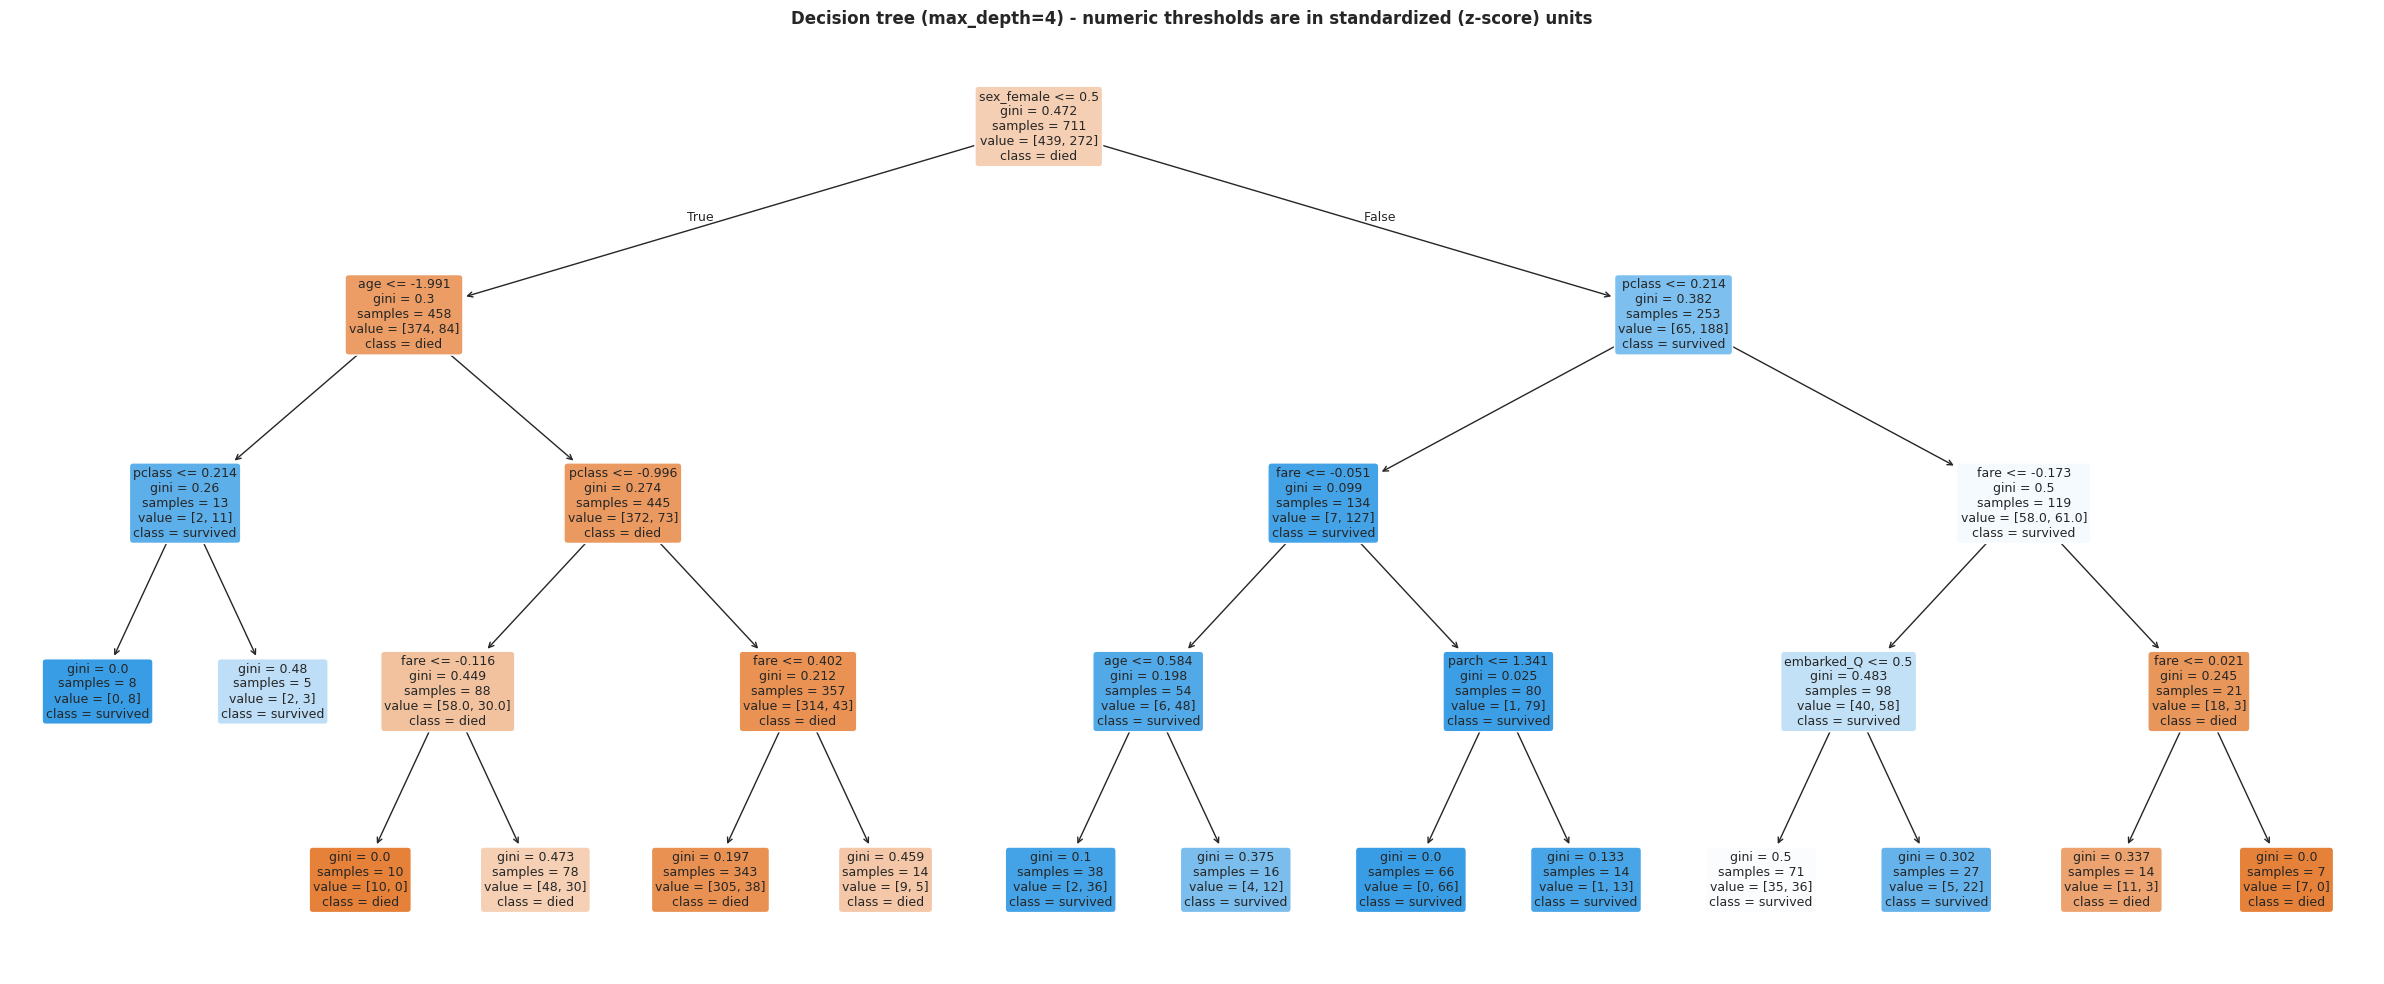

,node,feature,threshold (z),threshold (real units)
0,1,age,-1.991,3.50
1,2,pclass,0.214,2.50
2,5,pclass,-0.996,1.50
3,6,fare,-0.116,26.14
4,9,fare,0.402,51.70
5,12,pclass,0.214,2.50
6,13,fare,-0.051,29.36
7,14,age,0.584,37.00
8,17,parch,1.341,1.50
9,20,fare,-0.173,23.35


In [6]:
tree_pipe = models["Decision Tree"]
feature_names = [n.split("__", 1)[1] for n in tree_pipe.named_steps["prep"].get_feature_names_out()]

fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(tree_pipe.named_steps["model"], feature_names=feature_names, class_names=["died", "survived"],
          filled=True, rounded=True, fontsize=9, impurity=True, ax=ax)
ax.set_title("Decision tree (max_depth=4) - numeric thresholds are in standardized (z-score) units")
fig.tight_layout(); fig.savefig(CHARTS / "10_decision_tree.png", dpi=110); plt.show()

# Translate the scaled thresholds of the numeric features back to real units
scaler = tree_pipe.named_steps["prep"].named_transformers_["num"].named_steps["scale"]
tree = tree_pipe.named_steps["model"].tree_
rows = []
for node in range(tree.node_count):
    f = tree.feature[node]
    if f >= 0 and feature_names[f] in NUMERIC:
        i = NUMERIC.index(feature_names[f])
        rows.append((node, feature_names[f], round(tree.threshold[node], 3),
                     round(tree.threshold[node] * scaler.scale_[i] + scaler.mean_[i], 2)))
pd.DataFrame(rows, columns=["node", "feature", "threshold (z)", "threshold (real units)"]).head(12)

**Reading the tree.** The root split is `sex_female <= 0.5`, so sex is the most informative feature (the "True" branch on the left is male). On the male side the next split is `age <= 3.5 years`: very young boys mostly survived (11 of 13 in the training data). Among older males, class and fare separate a large group of 343 with only 11% survival. On the female side the split is `pclass <= 2.5`. 1st and 2nd class women survived almost without exception (127 of 134). 3rd-class women are split on fare, and those who paid more than about £23 (large families on a shared ticket) mostly died. The tree has learned the same story the EDA told. I limited it to `max_depth=4` and `min_samples_leaf=5` so it stays readable and doesn't memorize the training set. Numeric thresholds in the plot are in z-score units because the tree sits after the scaler; the table converts them back to years and pounds.

## Task 10 — Evaluate all three models

In [7]:
def evaluate(pipe, X_te=X_test, y_te=y_test):
    pred = pipe.predict(X_te)
    proba = pipe.predict_proba(X_te)[:, 1]
    return {
        "accuracy": accuracy_score(y_te, pred),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
        "f1": f1_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
    }

results = pd.DataFrame({name: evaluate(pipe) for name, pipe in models.items()}).T.round(3)
results

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.809,0.783,0.691,0.734,0.861
Decision Tree,0.798,0.776,0.662,0.714,0.851
Random Forest,0.803,0.762,0.706,0.733,0.824


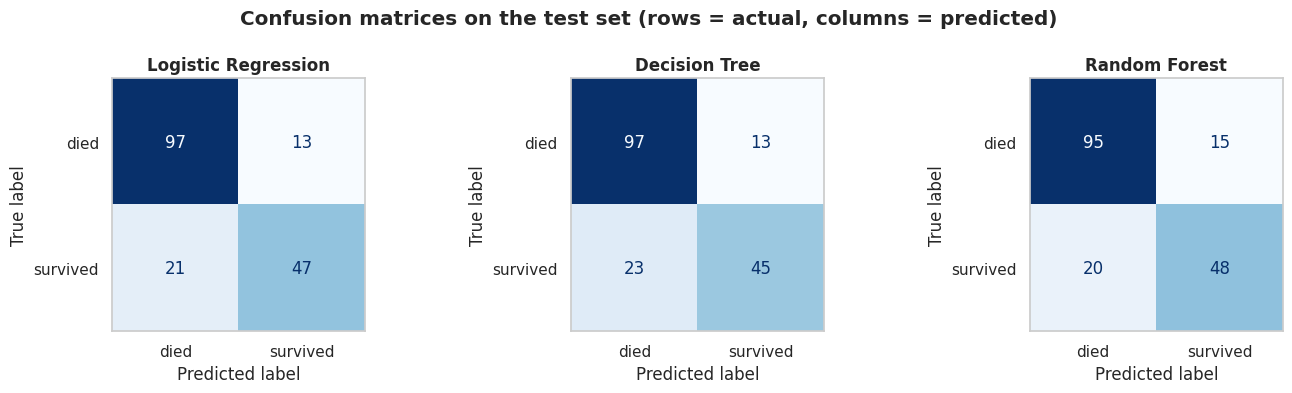

Logistic Regression  TN= 97  FP= 13  FN= 21  TP= 47
Decision Tree        TN= 97  FP= 13  FN= 23  TP= 45
Random Forest        TN= 95  FP= 15  FN= 20  TP= 48


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, pipe) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=["died", "survived"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name); ax.grid(False)
fig.suptitle("Confusion matrices on the test set (rows = actual, columns = predicted)", fontweight="bold")
fig.tight_layout(); fig.savefig(CHARTS / "11_confusion_matrices.png", dpi=120); plt.show()

for name, pipe in models.items():
    tn, fp, fn, tp = confusion_matrix(y_test, pipe.predict(X_test)).ravel()
    print(f"{name:<20} TN={tn:3d}  FP={fp:3d}  FN={fn:3d}  TP={tp:3d}")

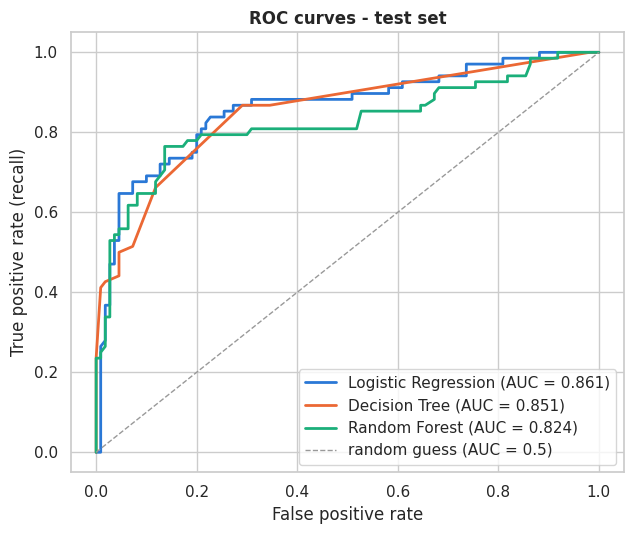

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
for name, pipe in models.items():
    fpr, tpr, _ = roc_curve(y_test, pipe.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, lw=2, color=MODEL_COLORS[name], label=f"{name} (AUC = {results.loc[name, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="#999999", lw=1, label="random guess (AUC = 0.5)")
ax.set(xlabel="False positive rate", ylabel="True positive rate (recall)", title="ROC curves - test set")
ax.legend(loc="lower right")
fig.tight_layout(); fig.savefig(CHARTS / "12_roc_curves.png", dpi=120); plt.show()

**How the three models compare** (test set, 178 passengers, 68 of whom survived):

- **Logistic Regression** has the best AUC (**0.861**) and the highest accuracy of the three untuned models (0.809). Its errors are balanced: 13 false alarms, 21 missed survivors.
- **Decision Tree** is slightly behind on everything (F1 0.714, AUC 0.851). It is the easiest to explain, but a single shallow tree loses some detail.
- **Random Forest (default settings)** has the best recall (**0.706**, 48 of 68 survivors found) but the lowest AUC (0.824). With no depth limit it scores 0.985 on the training data vs 0.803 on test. It is overfitting, and that makes its probability estimates less smooth, which is what AUC measures. Task 12 tunes this.

All three sit close together at 0.80–0.81 accuracy. They mostly miss the same kind of passenger: a man who survived or a 3rd-class woman who died, which are the cases that go against the main pattern.

## Task 11 — Imbalance handling: baseline vs `class_weight='balanced'` vs SMOTE

In [10]:
counts = y_train.value_counts().sort_index()
print(f"Training split class balance: died = {counts[0]} ({counts[0]/len(y_train):.1%}), "
      f"survived = {counts[1]} ({counts[1]/len(y_train):.1%}), ratio = {counts[0]/counts[1]:.2f} : 1")

lr = lambda **kw: LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, **kw)
variants = {
    "(a) baseline": make_pipeline(lr()),
    "(b) class_weight='balanced'": make_pipeline(lr(class_weight="balanced")),
    # imblearn's Pipeline runs SMOTE during fit() only - so it only ever sees the
    # training fold. At predict time the SMOTE step is skipped entirely.
    "(c) SMOTE (train fold only)": ImbPipeline([
        ("prep", make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", lr()),
    ]),
}
for pipe in variants.values():
    pipe.fit(X_train, y_train)

# Proof that SMOTE only touched the training data
smote_pipe = variants["(c) SMOTE (train fold only)"]
Xt = smote_pipe.named_steps["prep"].transform(X_train)
_, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(Xt, y_train)
print("train labels after SMOTE:", y_res.value_counts().sort_index().to_dict(),
      "| test set untouched:", y_test.value_counts().sort_index().to_dict())

imb = pd.DataFrame({name: evaluate(p) for name, p in variants.items()}).T[["precision", "recall", "f1", "accuracy", "roc_auc"]].round(3)
imb

Training split class balance: died = 439 (61.7%), survived = 272 (38.3%), ratio = 1.61 : 1
train labels after SMOTE: {0: 439, 1: 439} | test set untouched: {0: 110, 1: 68}


,precision,recall,f1,accuracy,roc_auc
(a) baseline,0.783,0.691,0.734,0.809,0.861
(b) class_weight='balanced',0.718,0.750,0.734,0.792,0.861
(c) SMOTE (train fold only),0.735,0.735,0.735,0.798,0.867


**Conclusion.** The training data is 1.61 : 1 (died : survived). All three variants use Logistic Regression on the same split.

- **(a) Baseline** has the highest precision (0.783) but misses the most survivors (recall 0.691). The model leans toward the majority "died" class.
- **(b) `class_weight='balanced'`** makes each survivor count about 1.6× more in the loss. Recall rises to **0.750** (4 more survivors found), precision falls to 0.718, and F1 stays at 0.734.
- **(c) SMOTE**, applied only inside `fit` on the training fold (439 : 439 after resampling, test set untouched), lands in between: precision = recall = **0.735**. It gives the **best F1 (0.735) and best AUC (0.867)**.

**SMOTE worked best, but only by a small margin.** It gave the best balance between catching survivors and not raising false alarms, and slightly improved ranking quality (AUC). The imbalance here is mild (38% minority), so all three F1 scores are within 0.001 of each other. The real effect of any strategy is to **trade precision for recall**. `class_weight='balanced'` gets most of SMOTE's recall gain with no synthetic rows, so it's the simpler choice if missing a survivor is the costly mistake. SMOTE sits inside an imblearn `Pipeline`, so it only runs during `fit()` and never on test data or during cross-validation scoring.

## Task 12 — `GridSearchCV` on the Random Forest, with OOB score

In [11]:
rf_pipe = make_pipeline(RandomForestClassifier(oob_score=True, bootstrap=True, random_state=RANDOM_STATE, n_jobs=-1))
param_grid = {
    "model__n_estimators": [100, 200, 400],
    "model__max_depth": [None, 4, 6, 8],
    "model__max_features": ["sqrt", "log2", 0.5],
}
grid = GridSearchCV(rf_pipe, param_grid, scoring="f1",
                    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
grid.fit(X_train, y_train)   # CV folds are made from the training split only

best_rf = grid.best_estimator_
print("combinations tried:", len(grid.cv_results_["params"]))
print("best parameters   :", {k.replace("model__", ""): v for k, v in grid.best_params_.items()})
print(f"best 5-fold CV F1 : {grid.best_score_:.3f}")
print(f"OOB score         : {best_rf.named_steps['model'].oob_score_:.3f}  (accuracy on out-of-bag training rows)")

combinations tried: 36
best parameters   : {'max_depth': 8, 'max_features': 0.5, 'n_estimators': 400}
best 5-fold CV F1 : 0.769
OOB score         : 0.826  (accuracy on out-of-bag training rows)


In [12]:
top = (pd.DataFrame(grid.cv_results_)
         .sort_values("rank_test_score")
         [["param_model__n_estimators", "param_model__max_depth", "param_model__max_features", "mean_test_score", "std_test_score"]]
         .head(8).round(3))
top.columns = ["n_estimators", "max_depth", "max_features", "mean CV F1", "std"]
top

,n_estimators,max_depth,max_features,mean CV F1,std
35,400,8,0.5,0.769,0.022
34,200,8,0.5,0.768,0.023
33,100,8,0.5,0.767,0.027
27,100,8,sqrt,0.763,0.037
30,100,8,log2,0.763,0.037
32,400,8,log2,0.762,0.028
29,400,8,sqrt,0.762,0.028
28,200,8,sqrt,0.759,0.029


In [13]:
models["Random Forest (tuned)"] = best_rf
results.loc["Random Forest (tuned)"] = pd.Series(evaluate(best_rf)).round(3)
results

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.809,0.783,0.691,0.734,0.861
Decision Tree,0.798,0.776,0.662,0.714,0.851
Random Forest,0.803,0.762,0.706,0.733,0.824
Random Forest (tuned),0.820,0.833,0.662,0.738,0.839


**Tuning result.** `GridSearchCV` tried all 36 combinations of `n_estimators` × `max_depth` × `max_features` with 5-fold stratified CV on the training split, scoring by F1. The model was built as `RandomForestClassifier(oob_score=True, …)`.

- **Best parameters: `n_estimators=400`, `max_depth=8`, `max_features=0.5`.**
- **Best CV F1: 0.769.**
- **OOB score: 0.826.** This is accuracy on the training rows each tree didn't see in its bootstrap sample, a free built-in validation estimate. It's close to the test accuracy of 0.820, so the model generalizes as expected.

`max_depth=8` beat `None` (unlimited) in every combination. Capping depth is what fixed the default forest's overfitting. Using half the features at each split (`0.5`) beat `sqrt` / `log2`, since with only 10 input columns `sqrt` gives each split just 3 to choose from. On the test set the tuned forest improves accuracy (0.803 → **0.820**), precision (0.762 → **0.833**), F1 (0.733 → **0.738**) and AUC (0.824 → 0.839), at the cost of some recall (0.706 → 0.662).

## Task 13 — Regression side-task: predict `fare`

In [14]:
REG_FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "embarked", "survived"]
Xr, yr = df[REG_FEATURES], df["fare"]
# Reuse the exact same rows for train/test as the classifiers
Xr_train, Xr_test = Xr.loc[X_train.index], Xr.loc[X_test.index]
yr_train, yr_test = yr.loc[X_train.index], yr.loc[X_test.index]

reg_pre = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]),
     ["pclass", "age", "sibsp", "parch", "survived"]),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))]), ["sex", "embarked"]),
])
reg = Pipeline([("prep", reg_pre), ("model", LinearRegression())]).fit(Xr_train, yr_train)

pred_r = reg.predict(Xr_test)
n, p = len(yr_test), len(reg.named_steps["prep"].get_feature_names_out())
r2 = r2_score(yr_test, pred_r)
reg_metrics = {
    "MAE": mean_absolute_error(yr_test, pred_r),
    "RMSE": np.sqrt(mean_squared_error(yr_test, pred_r)),
    "R2": r2,
    "Adjusted R2": 1 - (1 - r2) * (n - 1) / (n - p - 1),
}
print(f"test rows n = {n}, predictors p = {p}")
pd.Series(reg_metrics).round(3)

test rows n = 178, predictors p = 8


MAE            19.753
RMSE           41.270
R2              0.347
Adjusted R2     0.316
dtype: float64

In [15]:
coef = pd.Series(reg.named_steps["model"].coef_,
                 index=[c.split("__", 1)[1] for c in reg.named_steps["prep"].get_feature_names_out()])
print("Coefficients (per 1 std of each scaled feature, in GBP):")
print(coef.round(2).sort_values().to_string())

Coefficients (per 1 std of each scaled feature, in GBP):
pclass       -26.15
embarked_S   -18.03
embarked_Q   -13.18
sex_male      -5.07
age           -1.03
survived       1.68
sibsp          6.45
parch          8.46


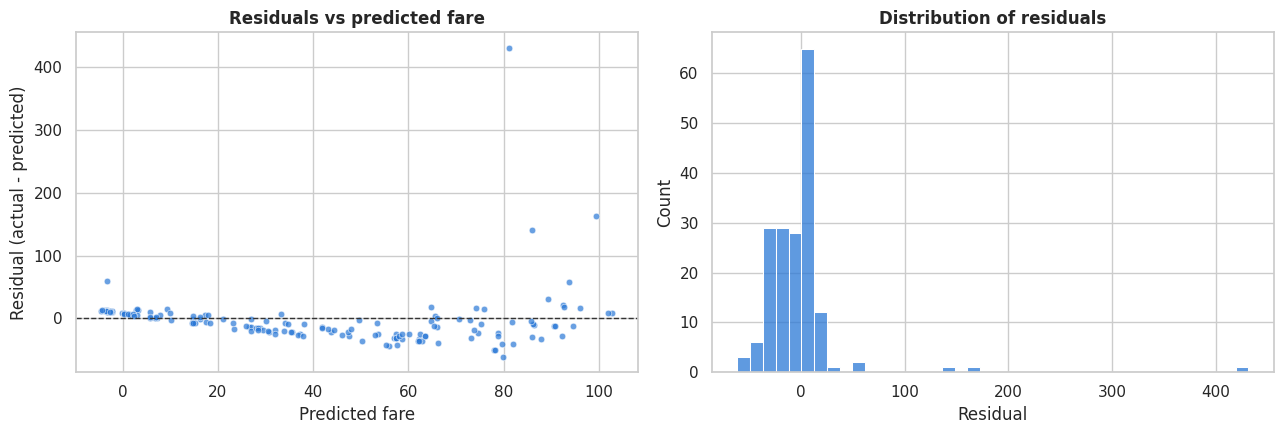

                      mean    std  size
band                                   
low predicted fare    9.71   7.39    60
middle               14.32   9.26    59
high predicted fare  35.40  59.20    59
corr(|residual|, predicted) = 0.324


In [16]:
resid = yr_test - pred_r
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(pred_r, resid, s=22, alpha=0.7, color=SURVIVED, edgecolor="white", linewidth=0.5)
axes[0].axhline(0, color="#333333", lw=1, ls="--")
axes[0].set(xlabel="Predicted fare", ylabel="Residual (actual - predicted)", title="Residuals vs predicted fare")
sns.histplot(resid, bins=40, color=SURVIVED, ax=axes[1])
axes[1].set(xlabel="Residual", title="Distribution of residuals")
fig.tight_layout(); fig.savefig(CHARTS / "13_regression_residuals.png", dpi=120); plt.show()

# A numeric check on the spread: residual size by prediction range
bands = pd.qcut(pred_r, 3, labels=["low predicted fare", "middle", "high predicted fare"])
spread = pd.DataFrame({"band": bands, "abs_resid": np.abs(resid.values)}).groupby("band", observed=True)["abs_resid"].agg(["mean", "std", "size"]).round(2)
print(spread)
print("corr(|residual|, predicted) =", round(np.corrcoef(np.abs(resid), pred_r)[0, 1], 3))

**Results.** On the same 178 test rows the linear model gets **MAE = £19.75, RMSE = £41.27, R² = 0.347, Adjusted R² = 0.316**. Adjusted R² uses n = 178 and p = 8 predictors after one-hot encoding. About a third of the variation in fare is explained, and almost all of that comes from `pclass` (−£26 per standard deviation) and port. RMSE is about twice MAE, which means a few very large errors dominate, not many medium ones.

**Heteroscedasticity: yes, clearly.** The residual plot is not a random, even band around zero. It fans out. For low predicted fares the residuals are tight (mean |error| **£9.71**). For the top third of predictions the mean |error| is **£35.40** with a standard deviation of **£59.20**, including one ticket under-predicted by over £400. The size of the error grows with the prediction (corr(|residual|, predicted) = 0.32). The residual histogram is also right-skewed rather than bell-shaped, and the model even predicts slightly negative fares for some 3rd-class passengers. All of this follows from `fare` being heavily right-skewed (notebook 01). A linear model on raw fare breaks the constant-variance assumption, so its confidence intervals would be unreliable. Modelling `log(fare)` instead would be the natural next step.

## Task 14 — Model comparison table

In [17]:
clf_cols = ["accuracy", "precision", "recall", "f1", "roc_auc"]
reg_cols = ["MAE", "RMSE", "R2", "Adjusted R2"]
rows = {name: {("Classification metrics (0-1, higher is better)", c): results.loc[name, c] for c in clf_cols}
        for name in results.index}
rows["Linear Regression (fare)"] = {("Regression metrics (fare in GBP)", c): round(v, 3) for c, v in reg_metrics.items()}
comparison = pd.DataFrame(rows).T
comparison.columns = pd.MultiIndex.from_tuples(comparison.columns)
comparison = comparison.reindex(columns=[("Classification metrics (0-1, higher is better)", c) for c in clf_cols]
                                        + [("Regression metrics (fare in GBP)", c) for c in reg_cols])
comparison.fillna("—")

Classification metrics (0-1, higher is better)                                 Regression metrics (fare in GBP)  \
                                                               accuracy precision recall     f1 roc_auc                              MAE   
Logistic Regression                                               0.809     0.783  0.691  0.734   0.861                                —   
Decision Tree                                                     0.798     0.776  0.662  0.714   0.851                                —   
Random Forest                                                     0.803     0.762  0.706  0.733   0.824                                —   
Random Forest (tuned)                                              0.82     0.833  0.662  0.738   0.839                                —   
Linear Regression (fare)                                              —         —      —      —       —                           19.753   

                                                    
                           RMSE     R2 Adjusted R2  
Logistic Regression           —      —           —  
Decision Tree                 —      —           —  
Random Forest                 —      —           —  
Random Forest (tuned)         —      —           —  
Linear Regression (fare)  41.27  0.347       0.316

The table keeps the two model types apart on purpose. Classification metrics are proportions between 0 and 1, where higher is better. Regression metrics are in **pounds** (MAE, RMSE, where lower is better) or are variance-explained ratios (R², Adjusted R²). Numbers in one group can't be compared with numbers in the other.

### Recommendation

**I would deploy the tuned Random Forest.** It has the highest test accuracy (**0.820**), precision (**0.833**) and F1 (**0.738**) of the four classifiers. Its OOB score (0.826) and CV F1 (0.769) agree with the test result, so the gain isn't a lucky split. Its AUC (0.839) is below Logistic Regression's **0.861**, so if the product needed well-ranked probabilities rather than yes/no decisions, or a model that's easy to explain, Logistic Regression would be the strong runner-up: F1 0.734, only 0.004 behind. The tuned forest's weak spot is recall (0.662). If missing a survivor were the expensive mistake, I would lower its decision threshold or add `class_weight='balanced'`, which Task 11 showed trades a little precision for about 6 points of recall.

## Task 15 — Save the complete pipeline, reload it, predict on raw data

In [18]:
BEST_NAME = 'Random Forest (tuned)'
best_pipeline = models[BEST_NAME]          # preprocessing + model in one object
path = MODELS / "titanic_best_pipeline.joblib"
joblib.dump(best_pipeline, path)
print(f"saved {BEST_NAME} pipeline -> {path} ({path.stat().st_size / 1024:.0f} KB)")
print(best_pipeline)

saved Random Forest (tuned) pipeline -> models/titanic_best_pipeline.joblib (4125 KB)
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                      

In [19]:
reloaded = joblib.load(path)

# 1) Reloaded pipeline gives identical predictions on the raw test rows
same = (reloaded.predict(X_test) == best_pipeline.predict(X_test)).all()
print("identical predictions on the test set after reload:", same)
print(f"test accuracy after reload: {accuracy_score(y_test, reloaded.predict(X_test)):.3f}")

# 2) Brand-new raw passengers: text categories, unscaled numbers, even a missing age
new_passengers = pd.DataFrame([
    {"pclass": 1, "sex": "female", "age": 29,     "sibsp": 0, "parch": 0, "fare": 110.0, "embarked": "C"},
    {"pclass": 3, "sex": "male",   "age": 24,     "sibsp": 0, "parch": 0, "fare": 7.25,  "embarked": "S"},
    {"pclass": 2, "sex": "male",   "age": 4,      "sibsp": 1, "parch": 1, "fare": 26.0,  "embarked": "S"},
    {"pclass": 3, "sex": "female", "age": np.nan, "sibsp": 1, "parch": 3, "fare": 25.47, "embarked": "Q"},
])
new_passengers["P(survive)"] = reloaded.predict_proba(new_passengers[FEATURES])[:, 1].round(3)
new_passengers["prediction"] = np.where(reloaded.predict(new_passengers[FEATURES]) == 1, "survived", "died")
new_passengers

identical predictions on the test set after reload: True
test accuracy after reload: 0.820


,pclass,sex,age,sibsp,parch,fare,embarked,P(survive),prediction
0,1,female,29.0,0,0,110.00,C,0.999,survived
1,3,male,24.0,0,0,7.25,S,0.078,died
2,2,male,4.0,1,1,26.00,S,0.777,survived
3,3,female,NaN,1,3,25.47,Q,0.580,survived


The reloaded object takes **raw** rows (text `sex`/`embarked`, fares in GBP, a missing `age`) and handles imputation, one-hot encoding and scaling itself before predicting. The predictions make sense: the 1st-class woman gets a high survival probability and the 3rd-class adult man a low one, in line with the EDA story. `predict.py` in this folder does the same reload from the command line.